## **Goal**
**Given a stereo image pair, use StereoSGBM to:**
* Get distance from camera to shoulder joint in the left image (left image center).

### **Setup**

```
conda create -n fbv-stereo-sgbm python=3.10
conda activate fbv-stereo-sgbm
pip install opencv-python
conda install matplotlib
conda install ipykernel=6.29.5
```

In [74]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### **Camera Constants**

In [75]:
# Givens

baseline = 0.1          # m
focal_length = 35.0     # mm
sensor_width = 36.0     # mm
image_width = 1920      # pixels

In [76]:
# Computed

focal_length_pixel = (focal_length * image_width) / sensor_width

### **Compute Disparity Map**

In [77]:
# Load Images

image_A = cv2.imread("00001A.png")
image_B = cv2.imread("00001B.png")

gray_A = cv2.cvtColor(image_A, cv2.COLOR_BGR2GRAY)
gray_B = cv2.cvtColor(image_B, cv2.COLOR_BGR2GRAY)

In [78]:
# Initialize SGBM object

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=160,
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=0,
    speckleRange=2,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

In [79]:
# Compute Disparity

disparity = stereo.compute(gray_A, gray_B).astype(np.float32) / 16.0

### **Calculate Camera-Shoulder Distnace**

In [80]:
# Assume Shoulder At Image Center (Replace With Predicted Later)

height, width = disparity.shape
center_y, center_x = height // 2, width // 2
disp_at_shoulder = disparity[center_y, center_x]

In [81]:
# Distance Output

if disp_at_shoulder > 0:
    distance = (focal_length_pixel * baseline) / disp_at_shoulder
    print(f"Distance to shoulder: {distance:.3f} meters")
else:
    print("Distance calculation failed: Disparity is zero or negative at center.")

Distance to shoulder: 5.938 meters


### **Visualize Disparity**

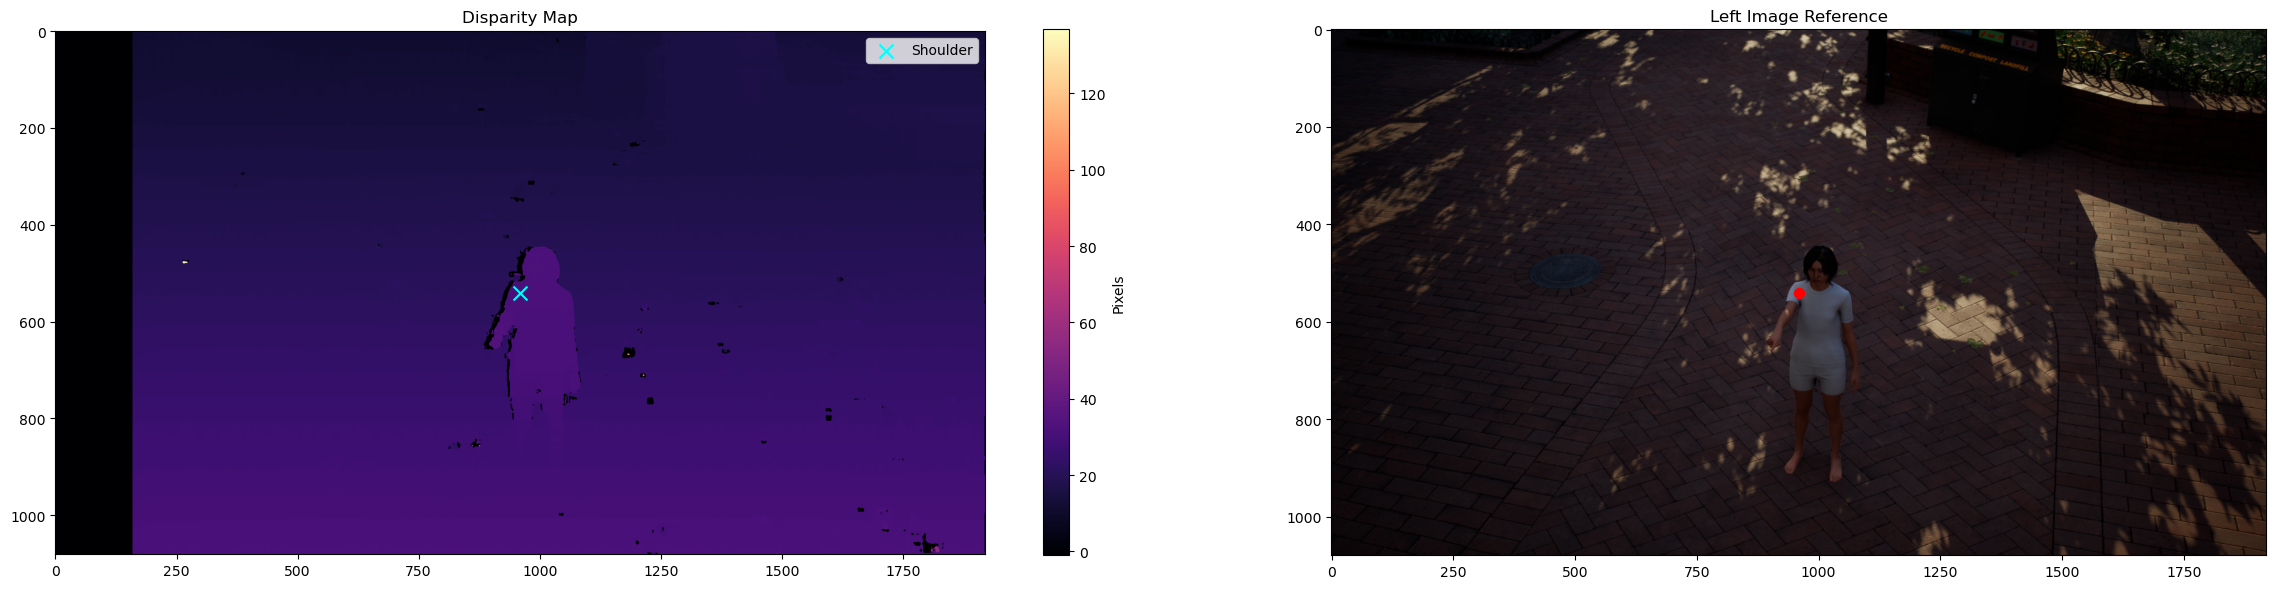

In [82]:
# Visualize Disparity

plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.title("Disparity Map")
plt.imshow(disparity, cmap='magma')
plt.colorbar(label='Pixels')
plt.scatter(center_x, center_y, color='cyan', marker='x', s=100, label='Shoulder')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Left Image Reference")
plt.imshow(cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB))
plt.scatter(center_x, center_y, color='red', marker='o', s=50)

plt.tight_layout()
plt.show()